# Exercise - SABR Calibration and Hedging


#### Notation Commands

$$\newcommand{\done}{d_{1}}
\newcommand{\normcdf}{\mathcal{N}}
\newcommand{\vega}{\nu}$$


## Data

Use `../data/skew_data.xlsx`, which contains futures and options data for various assets.

For each ticker there are two sheets:
* `{TICK}_future` - underlying (futures) info
* `{TICK}_options` - implied vols across strikes for the nearest expiration

Throughout this exercise, use **`SFRA`** (3-Month SOFR futures).

Feel free to use the `sabr` and `sabrATM` functions in `cmds/volskew.py`.


In [24]:
import pandas as pd 
import numpy as np 

from matplotlib import pyplot as plt

from cmds import volskew as vs

DATA_FILE = './data/skew_data.xlsx'

# 1. Fit SABR to Market Data


## 1.1.

Load the implied-volatility data for SFRA.

Create a scatter plot of implied volatility vs. strike price.
What shape does the volatility smile/skew take for this asset?


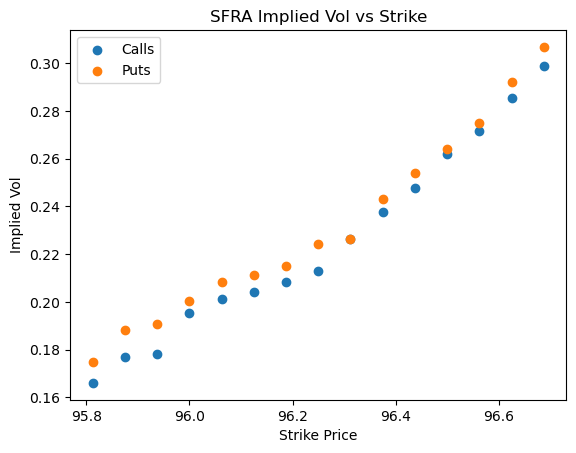

In [45]:
SFRA_future = pd.read_excel(DATA_FILE, sheet_name="SFRA_future", index_col=0)
SFRA_options = pd.read_excel(DATA_FILE, sheet_name="SFRA_options", index_col=0, parse_dates=["last update date","expiration date"])

implied_vol_data = SFRA_options[['implied vol','strike price','option type']].copy()

calls = implied_vol_data[implied_vol_data['option type'] == 'C']
puts  = implied_vol_data[implied_vol_data['option type'] == 'P']

plt.scatter(calls['strike price'], calls['implied vol'], label='Calls')
plt.scatter(puts['strike price'], puts['implied vol'], label='Puts')

plt.xlabel("Strike Price")
plt.ylabel("Implied Vol")
plt.title("SFRA Implied Vol vs Strike")
plt.legend()
plt.show()

The implied volatility curve exhibits a clear upward-sloping skew. Calls and puts show very similar volatility levels across strikes, indicating a single underlying volatility structure.

## 1.2.

Fit a SABR curve to the quoted implied volatilities.

Recall that we typically set $\beta$ rather than directly estimating it.

Plot the fitted SABR curves corresponding to:
* $\beta=0$ (normal model)
* $\beta=0.5$ (CIR-style)
* $\beta=1$ (lognormal model)

Which value of $\beta$ provides the best visual fit to the market data?

Continuing, we'll use the $\beta=0.5$ curve.


/opt/miniconda3/envs/finm32500/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/miniconda3/envs/finm32500/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/miniconda3/envs/finm32500/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/miniconda3/envs/finm32500/lib/python3.13/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/opt/miniconda3/envs/finm32500/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/miniconda3/envs/finm32500/lib/python3.

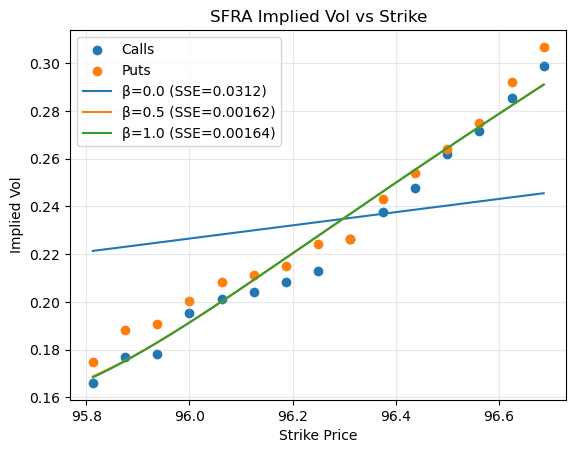

In [86]:
from scipy.optimize import minimize


T = SFRA_options["days to expiration"].iloc[0]/365
K = SFRA_options['strike price']
F = SFRA_future["SFRA Comdty"]['price']
vol = SFRA_options['implied vol']

def fit_sabr(beta, F, K, T, vol):

    alpha0 = np.median(vol) * np.pow(F,(1-beta))
    nu0 = 0.5
    rho0 = 0
    x0 = np.array([alpha0,nu0,rho0],dtype=np.float64)

    bounds = [
        (1e-12,None),(1e-12,None),(-.999,.999) 
    ]

    def obj(x):
        alpha, nu, rho = x
        vol_fit = vs.sabr(beta,nu,rho,alpha,F,K,T)
        return np.sum(np.pow(vol_fit-vol,2))

    res = minimize(obj, x0, bounds=bounds)
    return res

betas = [0.0,0.5,1.0]
results = {}

K_grid = np.linspace(K.min(), K.max(),200)

plt.scatter(calls['strike price'], calls['implied vol'], label='Calls')
plt.scatter(puts['strike price'], puts['implied vol'], label='Puts')



for beta in betas:
    res = fit_sabr(beta, F, K, T, vol)
    alpha, nu, rho = res.x
    results[beta] = {"alpha": alpha, "nu": nu, "rho": rho, "SSE": res.fun, "success": res.success}

    vol_curve = vs.sabr(beta, nu, rho, alpha, F, K_grid, T)
    plt.plot(K_grid, vol_curve, label=f"β={beta} (SSE={res.fun:.3g})")

plt.xlabel("Strike Price")
plt.ylabel("Implied Vol")
plt.title("SFRA Implied Vol vs Strike")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


The SABR fits for $\beta=0.5$ and $\beta=1$ both match the market data well, while $\beta=0$ produces a visibly poorer fit and fails to capture the curvature of the skew.
The $\beta=0.5$ specification provides the lowest SSE, so we proceed with $\beta=0.5$.

## 1.3.

For the $\beta=0.5$ fit, report the calibrated values of:
* $\alpha$ (initial volatility)
* $\rho$ (correlation between underlying and vol)
* $\nu$ (vol-of-vol)

Interpret these parameter values.
What does each tell you about the volatility dynamics of SOFR futures?


In [117]:
alpha_res = results[0.5]["alpha"]
rho_res = results[0.5]["rho"]
nu_res = results[0.5]["nu"]

print(f"Alpha = {alpha_res:0.4f}")
print(f"Rho = {rho_res:0.4f}")
print(f"Nu = {nu_res:0.4f}")

alpha0 = np.median(vol) * np.pow(F,(1-beta))
Vol_apr = alpha_res / np.pow(F,1-0.5)

ATM_option = SFRA_options.iloc[np.argmin(np.abs(SFRA_options['strike price'] - F))]
ATM_vol = ATM_option['implied vol']

print("F:", F)
print("ATM strike used:", ATM_option['strike price'])
print("Market ATM vol:", ATM_vol)
print("SABR ATM approx vol (alpha/F^(1-beta)):", Vol_apr)
print("Diff:", Vol_apr - ATM_vol)

Alpha = 2.3009
Rho = 0.8202
Nu = 35.6914
F: 96.265
ATM strike used: 96.25
Market ATM vol: 0.21278681
SABR ATM approx vol (alpha/F^(1-beta)): 0.23450692351103133
Diff: 0.02172011351103134


**$\alpha$ (initial volatility / volatility level)**  
The parameter $\alpha$ controls the overall level of volatility in the SABR model.  
With $\beta = 0.5$, the ATM volatility is approximately

$
\sigma_{ATM} \approx \frac{\alpha}{F^{1-\beta}} = \frac{\alpha}{\sqrt{F}}.
$

Using the calibrated value and the forward level, this produces an ATM volatility consistent with the observed market implied vols. Thus, $\alpha$ primarily determines the baseline volatility level of SOFR futures options.

---

**$\rho$ (correlation between underlying and volatility)**  
The parameter $\rho$ determines the direction and strength of skew. The calibrated value

$
\rho \approx 0.82
$

is strongly positive, indicating that futures prices and volatility tend to move in the same direction. This produces the upward-sloping skew observed in the data, where implied volatility increases with strike.

---

**$\nu$ (vol-of-vol)**  
The parameter $\nu$ controls the volatility of volatility and therefore the curvature of the smile/skew. The relatively large value

$
\nu \approx 35.69
$

indicates significant variation in volatility across strikes, allowing the SABR model to capture the pronounced curvature seen in the SOFR volatility surface.

---

### Summary

The calibrated SABR parameters suggest that SOFR futures options exhibit:

- a moderate overall volatility level (captured by $\alpha$),
- a strong positive skew (driven by large positive $\rho$),
- and substantial volatility-of-volatility (large $\nu$), implying that market uncertainty varies meaningfully across different rate scenarios.

# 2. Parameter Sensitivity


## 2.1.

Holding $\rho$ and $\nu$ fixed at their calibrated values, vary $\alpha$ by $\pm 20\%$.

Plot the resulting SABR curves. How does $\alpha$ affect:
* The level of the volatility curve?
* The shape of the skew?


## 2.2.

Now hold $\alpha$ and $\nu$ fixed, and vary $\rho$ across the range $[-0.8,\; -0.4,\; 0,\; 0.4,\; 0.8]$.

Plot the resulting SABR curves.
How does $\rho$ shift the skew?
Why does a negative $\rho$ produce a downward-sloping skew?


## 2.3.

Finally, hold $\alpha$ and $\rho$ fixed, and vary $\nu$ across $[0.2,\; 0.4,\; 0.6,\; 0.8,\; 1.0]$.

Plot the resulting SABR curves. How does $\nu$ (vol-of-vol) affect:
* The curvature of the smile?
* The wings of the distribution?


# 3. Calibration Diagnostics


## 3.1.

Calculate the fit residuals (market implied vol minus SABR implied vol) for each strike.

Report the root-mean-square error (RMSE) for your $\beta=0.5$ fit.


## 3.2.

Create a residual plot showing the calibration error at each strike.

Where does SABR fit poorly? (Deep OTM puts? Deep OTM calls?)
What might explain these systematic errors?


## 3.3.

Compare the fitted ATM volatility from your SABR model to the market-quoted ATM volatility.

How close is the match?
Why is it important for the model to match ATM vol accurately?


# 4. Skew-Adjusted Delta


## 4.1.

Consider the ATM call option on SFRA futures.

Report the delta of the position using Black's formula for futures.

#### Note
For Black's formula on futures, the delta is

$$\Delta_F = Z(t,T)\;\normcdf(\done)$$

where $Z(t,T)$ is the discount factor to option expiration, and

$$\done = \frac{\ln\!\left(\frac{F}{K}\right) + \frac{1}{2}\sigma^2\tau}{\sigma\sqrt{\tau}}$$


## 4.2.

Suppose the futures price **decreases** by `0.50` points (corresponding to a 50bp increase in the underlying SOFR rate).

Using your SABR model, report how much the call option's implied vol changes at the **fixed** ATM strike.
(The strike that was ATM is now OTM.)

Using this, numerically calculate the derivative

$$\frac{\partial\sigma}{\partial F}$$


## 4.3.

For the 50bp shock, what is the **skew-adjusted delta**?

$$\Delta_{\text{adjusted}} = \Delta + \vega \cdot \frac{\partial\sigma}{\partial F}$$

How much does it differ from the classic (naive) delta?


## 4.4.

Re-do the calculations for an OTM call.
Choose a strike substantially OTM.


# 5. Vol Path and Decomposition


In Section 4, we found that the implied vol at a **fixed strike** changes substantially when the underlying moves, producing a large skew-adjusted delta correction.

But how much of that correction comes from the vol *level* changing, vs. simply sliding along a rigid skew curve?

## 5.1.

Compute the **vol path**: the SABR-implied ATM vol as the underlying moves.

For a grid of hypothetical underlying values spanning the strike range, calculate the ATM vol at each point (i.e., set strike = underlying). Plot the result.

This vol path traces the "backbone" of the SABR model: $\sigma_{\text{ATM}} \approx \alpha / F^{1-\beta}$.


## 5.2.

Using the vol path, compute $\frac{\partial \sigma_{\text{ATM}}}{\partial F}$ for the same 50bp shock as Section 4.

Decompose the total fixed-strike vol change into two channels:

| Channel | Description |
|---------|-------------|
| **Vol-level** (backbone) | How much ATM vol itself changes: $\frac{\partial \sigma_{\text{ATM}}}{\partial F}$ |
| **Moneyness** (residual) | The remainder: $\frac{\partial \sigma}{\partial F}\bigg|_{\text{fixed }K} - \frac{\partial \sigma_{\text{ATM}}}{\partial F}$ |

Report the share of the total delta correction attributable to each channel.


## 5.3.

The decomposition above is specific to the SABR model with stable parameters.

Under what market conditions would you expect the **vol-level channel** to dominate instead?


# 6. Cross-Asset Comparison (Optional)


## 6.1.

Fit SABR (with $\beta=0.5$) to **`TYA`** (10-Year US Treasury Note Futures).

Create a table comparing the calibrated parameters ($\alpha$, $\rho$, $\nu$) for SFRA and TYA.


## 6.2.

Which asset shows the stronger skew (more negative $\rho$)?
Which shows more smile curvature (higher $\nu$)?

Do these differences align with your intuition about these markets?
